<a href="https://colab.research.google.com/github/amitshara/Google-Playstore-Project/blob/main/06.Task.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
import pytz

In [4]:
df = pd.read_csv("/content/Play Store Data.csv")

In [7]:
# Rating
df["Rating"] = pd.to_numeric(df["Rating"], errors="coerce")

# Reviews
df["Reviews"] = pd.to_numeric(df["Reviews"], errors="coerce")

In [8]:
#Install
df["Installs"] = (
    df["Installs"]
    .astype(str)
    .str.replace("+", "", regex=False)
    .str.replace(",", "", regex=False)
)
df["Installs"] = pd.to_numeric(df["Installs"], errors="coerce")

In [9]:
# Size (convert to MB)
def convert_size(size):
    try:
        size = str(size)

        if "M" in size:
            return float(size.replace("M", ""))

        elif "k" in size:
            return float(size.replace("k", "")) / 1024

        else:
            return np.nan
    except:
        return np.nan

df["Size_MB"] = df["Size"].apply(convert_size)

In [10]:
# Date
df["Last Updated"] = pd.to_datetime(
    df["Last Updated"],
    errors="coerce"
)


In [11]:
filtered_df = df[
    (df["Rating"] >= 4.2) &
    (~df["App"].str.contains(r"\d", na=False)) &
    (df["Category"].str.startswith(("T", "P"), na=False)) &
    (df["Reviews"] > 1000) &
    (df["Size_MB"].between(20, 80))
].copy()


In [19]:
ist = pytz.timezone("Asia/Kolkata")
current_time = datetime.now(ist)

if not (16 <= current_time.hour < 18):
    print("Chart is available only between 4 PM IST and 6 PM IST.")
else:

    # =========================
    # Monthly Aggregation
    # =========================

    filtered_df["Month"] = (
        filtered_df["Last Updated"]
        .dt.to_period("M")
        .astype(str)
    )

    monthly_installs = (
        filtered_df
        .groupby(["Month", "Category"])["Installs"]
        .sum()
        .reset_index()
    )

    p_df = monthly_installs.pivot(
        index="Month",
        columns="Category",
        values="Installs"
    ).fillna(0)

    pt_df = p_df.sort_index()


Chart is available only between 4 PM IST and 6 PM IST.


In [26]:
    translation_map = {
        "Travel & Local": "Voyage et Local",
        "Productivity": "Productividad",
        "Photography": "写真"
    }



NameError: name 'p_df' is not defined

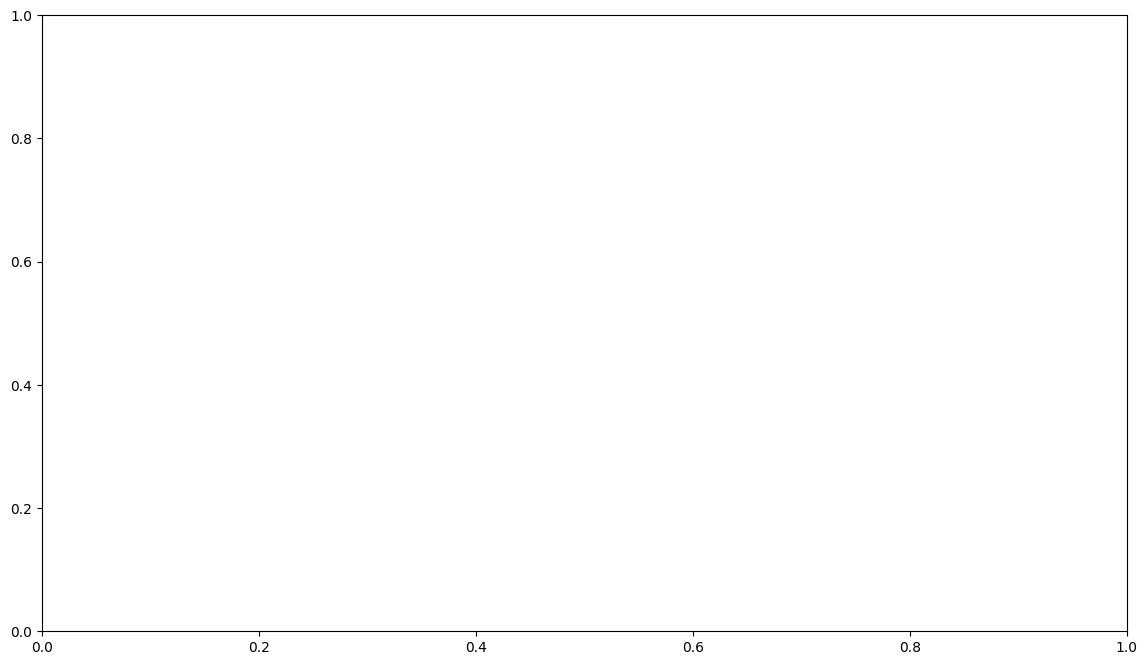

In [27]:
    fig, ax = plt.subplots(figsize=(14, 8))

    colors = plt.cm.tab20.colors[:len(p_df.columns)]

    ax.stackplot(
        p_df.index,
        p_df.T,
        labels=p_df.columns,
        colors=colors,
        alpha=0.7
    )

    # Highlight months where any category
    # increased >25% MoM
    for month in growth_months:
        idx = list(p_df.index).index(month)

        ax.axvspan(
            idx - 0.5,
            idx + 0.5,
            alpha=0.2,
            color="red"
        )

    ax.set_title(
        "Cumulative Installs Over Time by Category",
        fontsize=16
    )

    ax.set_xlabel("Month")
    ax.set_ylabel("Total Installs")

    ax.legend(
        title="Category",
        bbox_to_anchor=(1.05, 1),
        loc="upper left"
    )

    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()